In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer

In [9]:
df = pd.read_csv("titanic_toy.csv")

In [10]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [18]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [20]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [23]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].mean()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].mean()

In [24]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [26]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
421,21.0,7.7333,0,21.000000,21.000000,7.7333,7.7333
277,NaN,0.0000,0,29.498846,29.498846,0.0000,0.0000
278,7.0,29.1250,5,7.000000,7.000000,29.1250,29.1250
295,NaN,27.7208,0,29.498846,29.498846,27.7208,27.7208
865,42.0,13.0000,0,42.000000,42.000000,13.0000,13.0000


In [27]:

print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  210.2517072477438
Age Variance after median imputation:  168.8519336687225
Age Variance after mean imputation:  168.8519336687225
Original Fare variable variance:  2761.031434948639
Fare Variance after median imputation:  2621.2323749512393
Fare Variance after mean imputation:  2621.2323749512393


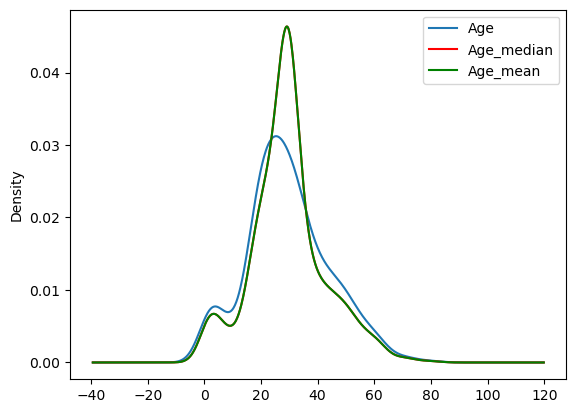

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax)

X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

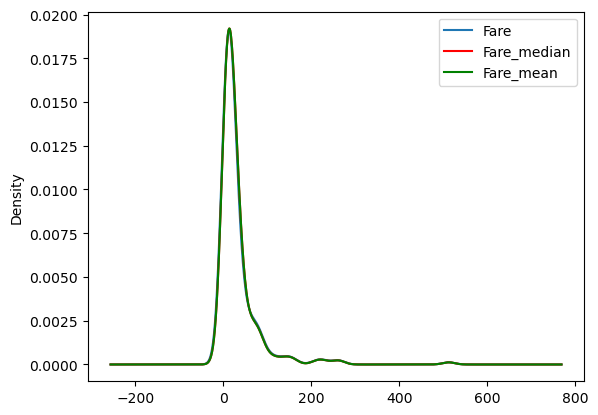

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind='kde', ax=ax)

X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [35]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,71.193767
Fare,75.481375,2761.031435,18.599163,60.224654,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.616299,17.657433,17.657433
Age_median,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,57.175304
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,57.175304
Fare_median,71.193767,2761.031435,17.657433,57.175304,57.175304,2621.232375,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,57.175304,57.175304,2621.232375,2621.232375


In [36]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.088944
Fare,0.091482,1.000000,0.207193,0.088151,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.256883,0.204981,0.204981
Age_median,1.000000,0.088151,-0.256883,1.000000,1.000000,0.085941,0.085941
Age_mean,1.000000,0.088151,-0.256883,1.000000,1.000000,0.085941,0.085941
Fare_median,0.088944,1.000000,0.204981,0.085941,0.085941,1.000000,1.000000
Fare_mean,0.088944,1.000000,0.204981,0.085941,0.085941,1.000000,1.000000


<Axes: >

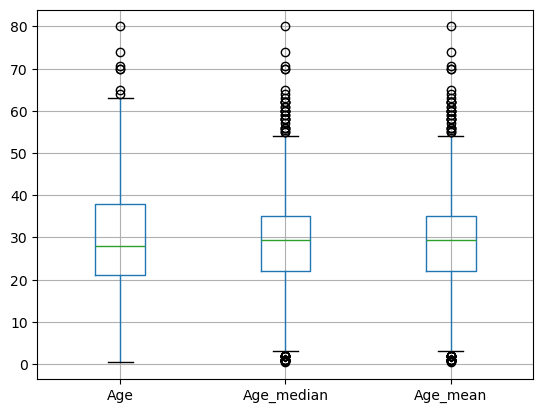

In [37]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

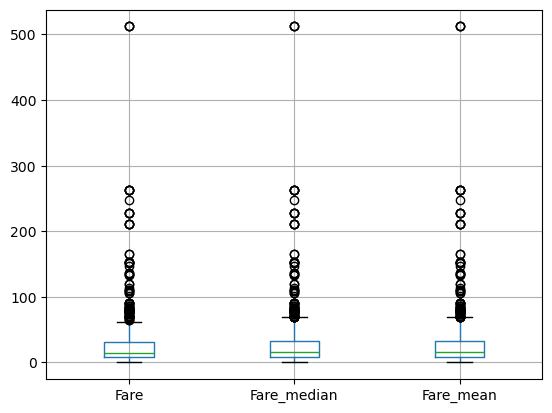

In [38]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

In [39]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [40]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [44]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [45]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [47]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [50]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [51]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [52]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))